In [2]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
import sys 
import os
sys.path.append(os.path.abspath(".."))
from src.Linear_Model.Gaussian_Analysis import GDA
from sklearn.preprocessing import LabelEncoder


In [3]:
df=pd.read_csv("../data/data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

c:\Users\AFROCHEM\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


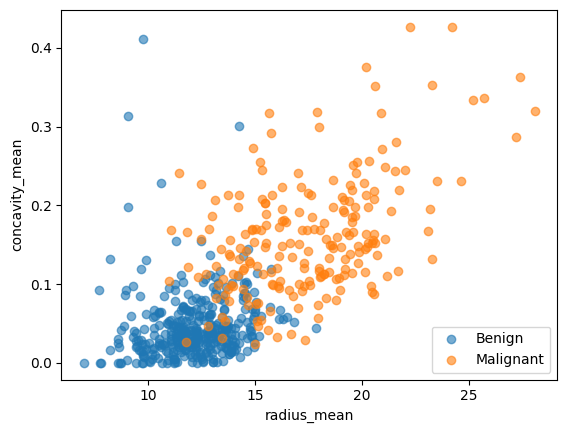

In [4]:
encoder=LabelEncoder()
df['diagnosis']=encoder.fit_transform(df[['diagnosis']])
Y=df['diagnosis'].values
X=df.drop(columns=['id','diagnosis','Unnamed: 32']).values# every column except those listed
plt.scatter(
    X[Y==0, 0],  # first feature
    X[Y==0, 6],  # seventh feature
    label="Benign",
    alpha=0.6
)

plt.scatter(
    X[Y==1, 0],
    X[Y==1, 6],
    label="Malignant",
    alpha=0.6
)

plt.xlabel("radius_mean")
plt.ylabel("concavity_mean")
plt.legend()
plt.show()

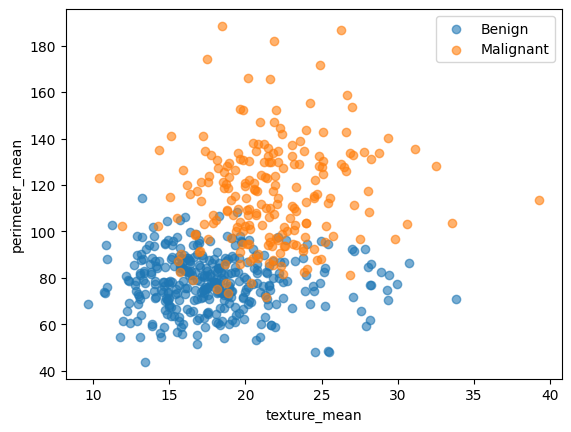

In [5]:
plt.scatter(
    X[Y==0, 1],  # second feature
    X[Y==0, 2],  # third feature
    label="Benign",
    alpha=0.6
)

plt.scatter(
    X[Y==1, 1],
    X[Y==1, 2],
    label="Malignant",
    alpha=0.6
)

plt.xlabel("texture_mean")
plt.ylabel("perimeter_mean")
plt.legend()
plt.show()

In [6]:
model=GDA()
x_train,x_test,y_train,y_test=train_test_split(X,Y)
model.fit(x_train,y_train)


In [7]:
accuracy=accuracy_score(y_test,model.predict(x_test))
print("Accuracy:",accuracy*100)

Accuracy: 93.7062937062937
